# EEG Signal Quality Detection

This notebook demonstrates how to **automatically assess the quality** of a NeuraDock EEG recording and how to **reject the contaminated segments** before any downstream analysis.

All of the heavy lifting is done by helper functions in `Neuradock_library.py`, so the workflow is only a few lines long.

## What we check

The recording is split into short **1-second segments** (250 samples at 250 Hz). For every channel and every segment three quality metrics are computed:

| Metric | Band / Rule | What it catches |
|--------|-------------|-----------------|
| **50 Hz power** | 49–51 Hz | Power-line interference (bad grounding / mains pickup) |
| **EMG power**   | 20–40 Hz | Muscle activity (jaw clench, frowning, movement) |
| **Outlier count** | \|x\| ≥ 100 µV | Electrode pops, motion artefacts, saturation |

Each metric is compared against a hardware-tuned threshold `[50Hz=10, EMG=20, Outlier=2]`. Segments above threshold are highlighted, and channels that are bad for more than 40 % of the recording are flagged as **bad channels**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# NeuraDock quality-control helpers
from Neuradock_library import (
    text2data_bluetooth,        # raw .txt  ->  (7, N) array
    eeg_quality_check,          # compute metrics + draw diagnostics
    clean_eeg_data,             # drop contaminated segments
    visualize_cleaning_comparison,  # before/after comparison plot
)

print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load the recording

We use the bundled `example_data_bluetooth.txt`. Replace the filename with any of your own recordings (e.g. `rest_20251024160452_2m12s.txt`) to inspect them.

In [2]:
fs = 250  # NeuraDock sampling rate (Hz)

eeg_data = text2data_bluetooth('example_data_bluetooth.txt')

n_channels, n_points = eeg_data.shape
print(f'Data shape    : {eeg_data.shape}')
print(f'Duration      : {n_points / fs:.1f} s')
print(f'Channels      : {n_channels}')
print(f'Sampling rate : {fs} Hz')

Data shape    : (7, 2325)
Duration      : 9.3 s
Channels      : 7
Sampling rate : 250 Hz


## Step 2 — Run the quality check

`eeg_quality_check` returns a list `[res_50hz, res_emg, res_out]`, where each element has shape `(n_channels, n_segments)`. It also draws two diagnostic figures:

1. **Time-domain view** — every channel's waveform with bad segments shaded (red = 50 Hz, blue = EMG, gray = outliers).
2. **Heatmaps** — one per metric (green = clean, red = above threshold), so you can spot problem channels/segments at a glance.

Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 9 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


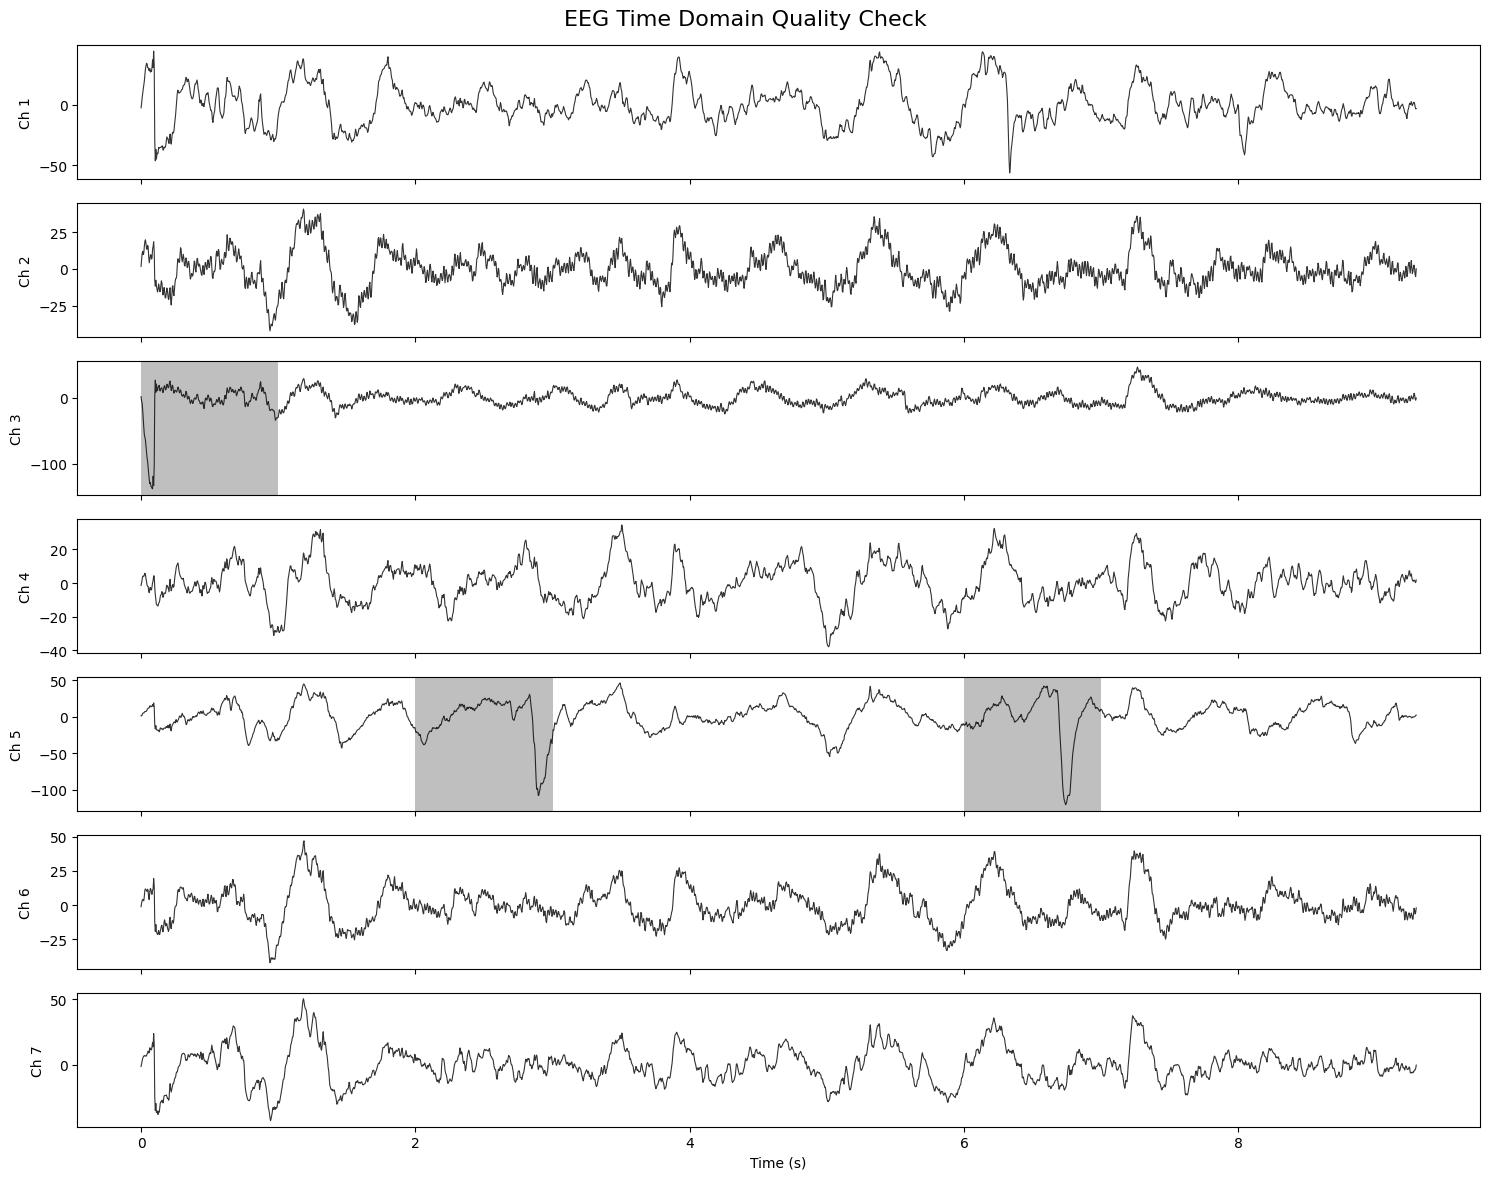

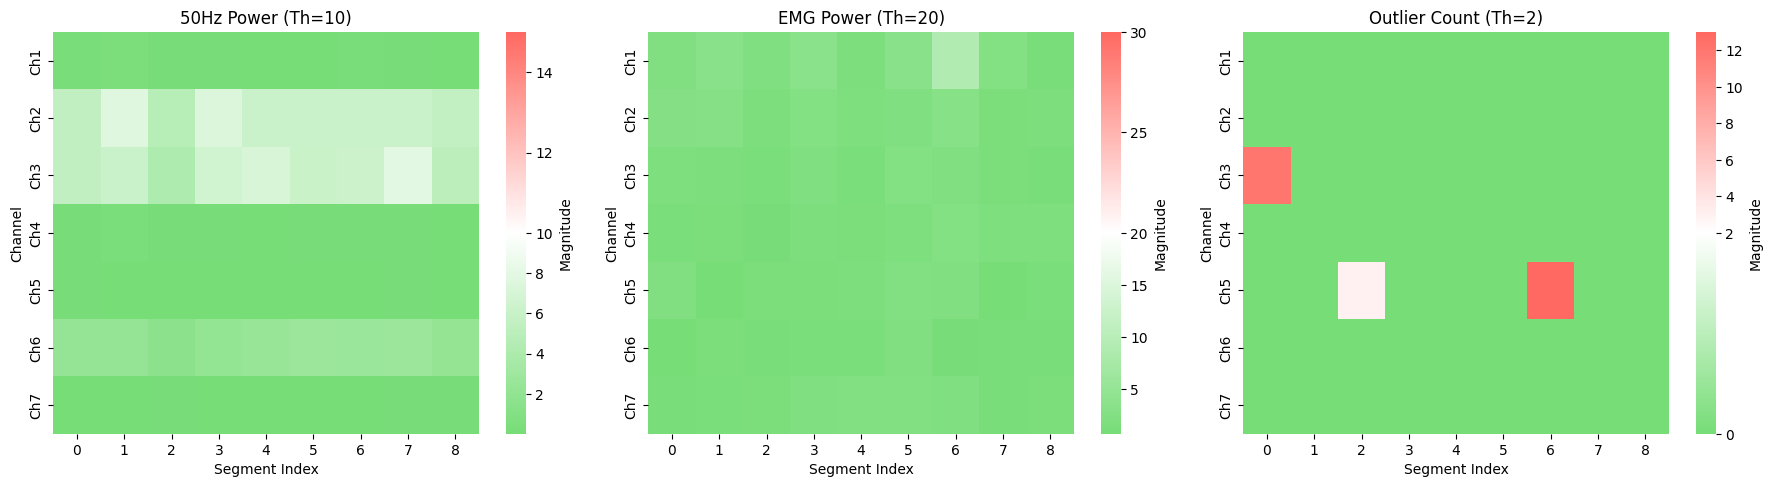

Metric matrices (channels x segments):
  50 Hz : (7, 9)
  EMG   : (7, 9)
  Outlier: (7, 9)


In [3]:
metrics = eeg_quality_check(eeg_data, fs=fs)

res_50hz, res_emg, res_out = metrics
print('Metric matrices (channels x segments):')
print('  50 Hz :', res_50hz.shape)
print('  EMG   :', res_emg.shape)
print('  Outlier:', res_out.shape)

## Step 3 — Per-channel summary

The same thresholds used inside the library let us turn the metric matrices into a simple **fraction-of-bad-segments** table per channel. Channels above 40 % are the ones `clean_eeg_data` will flag as bad.

In [4]:
thresh = [10, 20, 2]   # [50Hz, EMG, Outlier] — must match eeg_quality_check

bad_mask = (metrics[0] > thresh[0]) | (metrics[1] > thresh[1]) | (metrics[2] > thresh[2])
bad_ratio = bad_mask.mean(axis=1)   # fraction of bad segments per channel

print('Channel | bad-segment ratio | status')
print('-' * 42)
for ch in range(n_channels):
    status = 'BAD' if bad_ratio[ch] > 0.4 else 'ok'
    print(f'  Ch{ch+1:<2}  |       {bad_ratio[ch]:5.1%}       | {status}')

Channel | bad-segment ratio | status
------------------------------------------
  Ch1   |        0.0%       | ok
  Ch2   |        0.0%       | ok
  Ch3   |       11.1%       | ok
  Ch4   |        0.0%       | ok
  Ch5   |       22.2%       | ok
  Ch6   |        0.0%       | ok
  Ch7   |        0.0%       | ok


## Step 4 — Clean the data

`clean_eeg_data` uses the metrics to:

- identify **bad channels** (bad for > `bad_ch_ratio` of the time), and
- **cut out** the time segments that are contaminated on the *good* channels (these usually indicate subject movement / global interference).

It returns the spliced clean data, a boolean keep-mask, and an `info` dict.

In [5]:
clean_data, keep_mask, info = clean_eeg_data(
    eeg_data, metrics, thresh,
    seg_len=250,        # 1-second segments
    bad_ch_ratio=0.4,   # > 40% bad  ->  bad channel
)

print()
print(f'Bad channels    : {info["bad_channels"]}')
print(f'Retention rate  : {info["retention_rate"]:.1%}')
print(f'Clean data shape: {clean_data.shape}')

Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 2325 -> cleaned 1575
Information retention rate: 67.74%

Bad channels    : []
Retention rate  : 67.7%
Clean data shape: (7, 1575)


## Step 5 — Before / after comparison

Finally we visualise the result. The top panel shows the raw signal with rejected segments shaded red and bad channels drawn as red dashed lines; the bottom panel shows the concatenated clean signal.

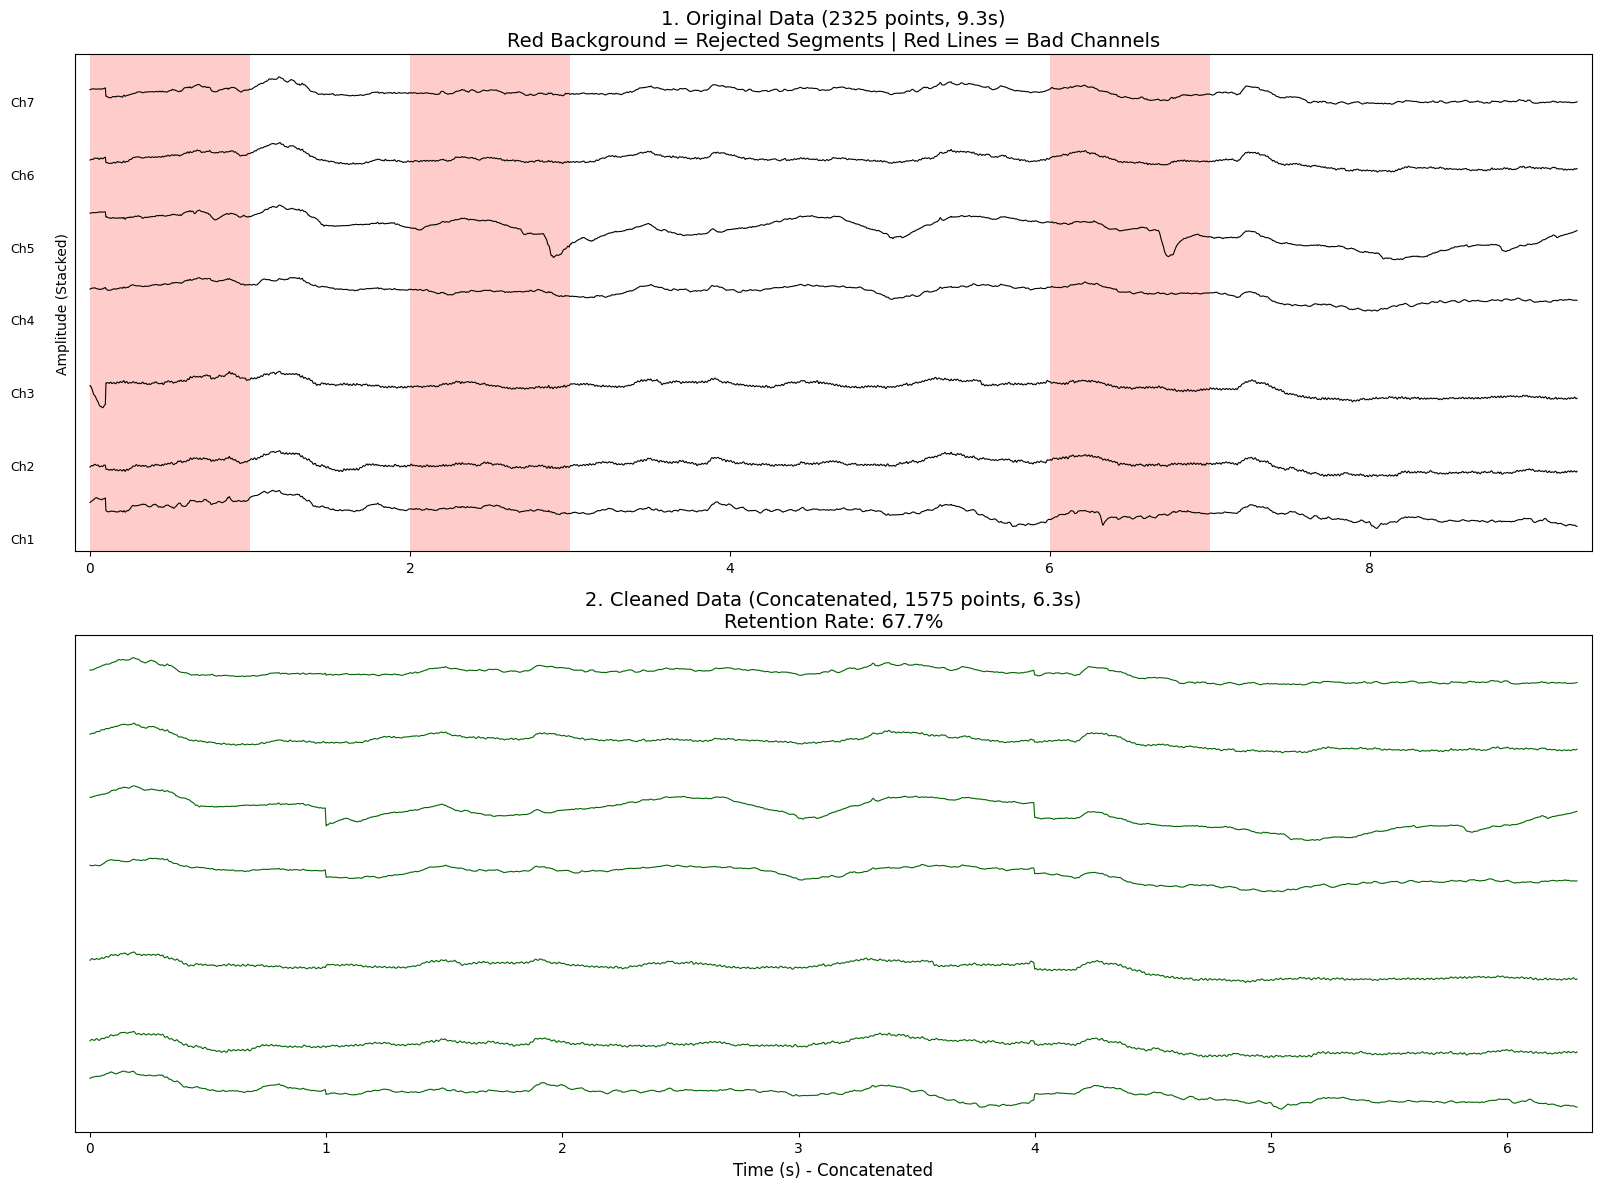

In [6]:
visualize_cleaning_comparison(eeg_data, clean_data, keep_mask, info, fs=fs)

## Notes & tuning

- **Thresholds** `[10, 20, 2]` are tuned for NeuraDock dry electrodes. If your environment is noisier (or cleaner), adjust them — just keep the value passed to `clean_eeg_data` identical to the one used inside `eeg_quality_check`.
- **Segment length** defaults to 1 s (`seg_len=250`). Shorter segments give finer rejection but noisier metric estimates.
- **Bad-channel ratio** (`bad_ch_ratio`) controls how tolerant you are: lower it to drop flaky channels more aggressively.
- Swap `example_data_bluetooth.txt` for `rest_*.txt` / `task_*.txt` to quality-check longer recordings (the heatmaps become more informative with more segments).